# 📊 **Exploratory Data Analysis — BTC Price × Media**

### 🎯 **Objective**
Assess whether **media activity and tone** add useful signal on top of BTC market features for crash prediction.

### ⚠️ **Target Definition**
A crash is defined as a price drop of more than **10% within the next 7 days** — the same definition as in notebook 01 (BTC EDA).

- `1` → Crash
- `0` → No crash

### 🔬 **EDA Focus**
1. Check dataset alignment between price and media data
2. Merge both sources at the daily level
3. Measure linear, monotonic, and non-linear dependencies with the target
4. Select media features using a combined score (Spearman + MI)
5. Build a compact feature set for benchmarking

### 🚀 **Goal**
Determine whether **media-derived variables** bring complementary information beyond market momentum, volatility, and drawdown — and if so, which ones.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from pipelines.ml_benchmark import run_benchmark_pipeline

In [17]:
df_btc_price = pd.read_csv("../../data/gold/market/btc_usdt_1d_features.csv")
df_btc_media = pd.read_csv("../../data/gold/bitcoin_tone_gold.csv")

### 1. Initial Data Overview


In [18]:
df_btc_media.head()

,date,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1
0,2017-08-30,-0.645120,130,-0.514932,-0.554371,0.000000,-0.137713,101.000000,0
1,2017-08-31,-0.519264,281,-0.535172,-0.532671,-0.645120,-0.377583,137.000000,130
2,2017-09-01,-0.326897,270,-0.550405,-0.518553,-0.519264,-0.220268,227.000000,281
3,2017-09-02,-0.416998,211,-0.523422,-0.499063,-0.326897,-0.605876,254.000000,270
4,2017-09-03,-1.110802,150,-0.608472,-0.492920,-0.416998,-0.515453,210.333333,211


In [19]:
print(f"{df_btc_price.shape[0]} rows and {df_btc_price.shape[1]} columns in the price dataset.")
print(f"{df_btc_media.shape[0]} rows and {df_btc_media.shape[1]} columns in the media dataset.")


3115 rows and 30 columns in the price dataset.
3145 rows and 9 columns in the media dataset.


**Observation:**
The media source (`bitcoin_tone_gold.csv`) is a **bitcoin-specific gold file** (3 145 rows, 9 columns). It now covers **2017–2026** with gap days filled as zero-coverage entries (`article_count=0, avg_tone=0.0`). No coin filtering is required.

**Impact:**
The media file now covers approximately the same date range as the BTC price dataset (3 115 rows). The inner join is expected to retain nearly all price rows — the training window spans the full available BTC history.


In [20]:
df_btc_price[df_btc_price["open_time"] == df_btc_price["open_time"].min()]

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,...,lag_volume_norm,lag_buy_pressure,momentum_acc,volatility_ratio,momentum_volatility,pressure_x_return,ma_7,ma_30,ma_ratio,target
0,2017-09-16,3674.01,3950.0,3470.66,3714.95,1297.563953,4.804878e+06,8809,624.887842,2.314536e+06,...,2.390714,0.4907,-0.156191,1.727747,-0.013297,0.001946,3864.46,4239.663667,0.911502,1


### 2. Time Alignment and Daily Aggregation

The media source is a **bitcoin-specific gold file** (`bitcoin_tone_gold.csv`) with **9 pre-engineered columns**: `avg_tone`, `article_count`, and derived features (`tone_ma_7`, `tone_ma_30`, `tone_lag_1`, `tone_lag_7`, `article_count_ma_3`, `article_count_lag_1`).

The dates in this file are standard ISO `YYYY-MM-DD` strings. A direct `pd.to_datetime` conversion is applied, followed by filtering to the price dataset's date range and deduplication. The media and price series are then joined via an **inner join** — only days present in both datasets are kept.


In [21]:
print(f"Media dataset: {df_btc_media.shape[0]} rows, {df_btc_media.shape[1]} columns")
print(f"Media columns: {list(df_btc_media.columns)}")
print(f"Media date range (raw): {df_btc_media['date'].min()} to {df_btc_media['date'].max()}")

Media dataset: 3145 rows, 9 columns
Media columns: ['date', 'avg_tone', 'article_count', 'tone_ma_7', 'tone_ma_30', 'tone_lag_1', 'tone_lag_7', 'article_count_ma_3', 'article_count_lag_1']
Media date range (raw): 2017-08-30 to 2026-04-09


In [22]:
df_btc_price["open_time"] = pd.to_datetime(df_btc_price["open_time"], errors="coerce")
df_btc_media["date"] = pd.to_datetime(df_btc_media["date"], errors="coerce")

min_price_date = df_btc_price["open_time"].min()
max_price_date = df_btc_price["open_time"].max()

print(f"{type(df_btc_price).__name__} price range: {min_price_date.date()} to {max_price_date.date()}")
print(f"Media range (raw): {df_btc_media["date"].min().date()} to {df_btc_media["date"].max().date()}")
print(f"Valid media dates: {df_btc_media["date"].notna().sum()}")

df_btc_media = (
    df_btc_media
    .dropna(subset=["date"])
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .reset_index(drop=True)
)

df_btc_media = df_btc_media[
    (df_btc_media["date"] >= min_price_date) &
    (df_btc_media["date"] <= max_price_date)
].copy()

print(f"After filtering to price range: {df_btc_media.shape[0]} media rows remain")
df_btc_media.head()

DataFrame price range: 2017-09-16 to 2026-03-27
Media range (raw): 2017-08-30 to 2026-04-09
Valid media dates: 3145
After filtering to price range: 3115 media rows remain


,date,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1
17,2017-09-16,-1.715865,372,-1.895764,-0.872188,-2.099644,-1.382756,776.666667,1020
18,2017-09-17,-1.658053,287,-1.998736,-0.911391,-1.715865,-0.937248,559.666667,372
19,2017-09-18,-1.314142,634,-1.939380,-0.948492,-1.658053,-1.729629,431.000000,287
20,2017-09-19,-1.070752,586,-1.777034,-0.988215,-1.314142,-2.207177,502.333333,634
21,2017-09-20,-0.978995,400,-1.599995,-1.017923,-1.070752,-2.218269,540.000000,586


**Observation:**
Both the price file and the media file use plain ISO date strings (`YYYY-MM-DD`) — no year-offset correction is needed. A direct `pd.to_datetime` conversion is sufficient.

**Conclusion:**
Date alignment is straightforward. The inner join retains dates present in both files.

### 3. Merged BTC + Media Dataset


In [23]:
df_btc_media_and_price = pd.merge(df_btc_price, df_btc_media, left_on="open_time", right_on="date", how="inner")
print(f"Merged dataset: {df_btc_media_and_price.shape[0]} rows, {df_btc_media_and_price.shape[1]} columns")
df_btc_media_and_price.drop(columns=["open_time", "date"], inplace=True)
df_btc_media_and_price.head()

Merged dataset: 3115 rows, 39 columns


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,return_1d,...,ma_ratio,target,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1
0,3674.01,3950.00,3470.66,3714.95,1297.563953,4.804878e+06,8809,624.887842,2.314536e+06,0.004041,...,0.911502,1,-1.715865,372,-1.895764,-0.872188,-2.099644,-1.382756,776.666667,1020
1,3685.23,3748.21,3499.02,3699.99,682.171210,2.466490e+06,6355,273.931976,9.948436e+05,-0.004027,...,0.899889,1,-1.658053,287,-1.998736,-0.911391,-1.715865,-0.937248,559.666667,372
2,3690.00,4123.20,3690.00,4035.01,1030.006455,4.069033e+06,8220,417.638722,1.651863e+06,0.090546,...,0.894766,1,-1.314142,634,-1.939380,-0.948492,-1.658053,-1.729629,431.000000,287
3,4060.00,4089.97,3830.91,3910.04,902.332129,3.558315e+06,7342,257.320352,1.016804e+06,-0.030971,...,0.887418,1,-1.070752,586,-1.777034,-0.988215,-1.314142,-2.207177,502.333333,634
4,3910.04,4046.08,3820.00,3900.00,720.935076,2.839584e+06,7231,395.275138,1.562210e+06,-0.002568,...,0.886718,0,-0.978995,400,-1.599995,-1.017923,-1.070752,-2.218269,540.000000,586


**Observations:**
- The merged dataset has **3 115 rows** (2017-09-16 to 2026-03-27) and 37 columns: 28 market features + 8 media features + target.
- This is a **substantial dataset** — it spans nearly 9 years of BTC market history across multiple full market cycles.
- The `avg_tone` in the first rows (Sept 2017) is around **-0.5 to -2.4**, reflecting generally cautious media sentiment during the early BTC adoption period before the 2017 bull run.
- The `article_count` in early rows (Sept 2017) is around **280–370 articles/day**, confirming that BTC already had substantial media coverage from the beginning of our price dataset.

**Conclusion:**
The merged dataset is clean with no missing values (inner join). The training window covers the full BTC price history — 3 115 rows — providing statistically reliable correlation and MI estimates.


### 4. Correlation Between Features and Target

**Objective**
Compare market and media variables using three views:
- Pearson for linear effects
- Spearman for monotonic effects
- Mutual Information for non-linear dependencies


**Pearson Correlation with Target**


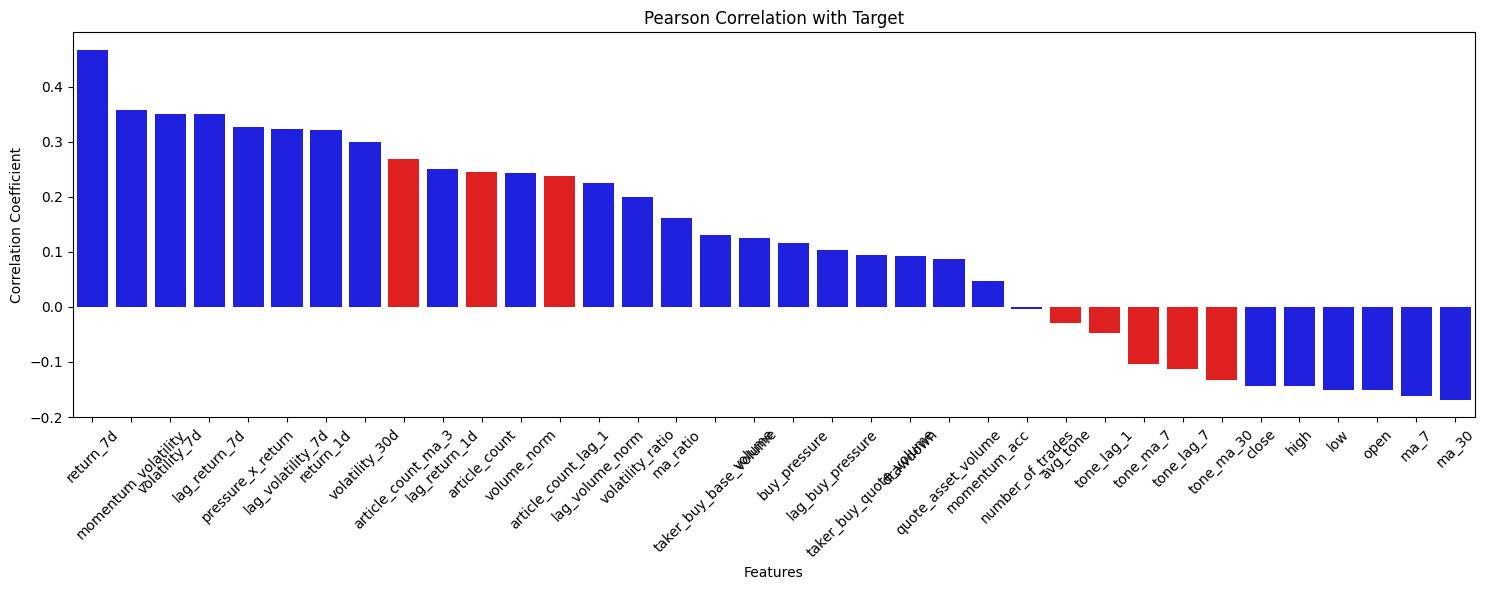

In [24]:
# Pearson correlation with target
corrs_pearson = (
    df_btc_media_and_price
    .corr(method="pearson")["target"]
    .sort_values(ascending=False)
    .drop("target")
)

media_cols = ["avg_tone", "article_count", "tone_ma_7", "tone_ma_30", "tone_lag_1", "tone_lag_7", "article_count_ma_3", "article_count_lag_1"]
colors = ["red" if col in media_cols else "blue" for col in corrs_pearson.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=corrs_pearson.index, y=corrs_pearson.values, hue=corrs_pearson.index, palette=dict(zip(corrs_pearson.index, colors)), legend=False)
plt.xticks(rotation=45)
plt.title("Pearson Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


**Observations:**
- Market features dominate: **momentum and return features** (`momentum_volatility`, `return_7d`, `lag_return_7d`) rank among the strongest linear predictors across the full 2017-2026 BTC history.
- Among media features, **`article_count` and its derivatives** (`article_count_ma_3`, `article_count`, `article_count_lag_1`) show the strongest linear correlation with the crash target — more media coverage tends to co-occur with crash periods.
- **Smoothed tone features** (`tone_ma_30`, `tone_ma_7`) rank second among media features for linear signal. `avg_tone` shows the weakest linear correlation.
- This finding is consistent with the combined score results: BTC media volume is a stronger predictor than tone on the full dataset.

**Conclusion:**
Red bars (media features) cluster below market features, but `article_count` and its derivatives show the clearest linear signal among media features on the full 3 115-row dataset — a reversal from what smaller samples suggested.


**Spearman Correlation with Target**


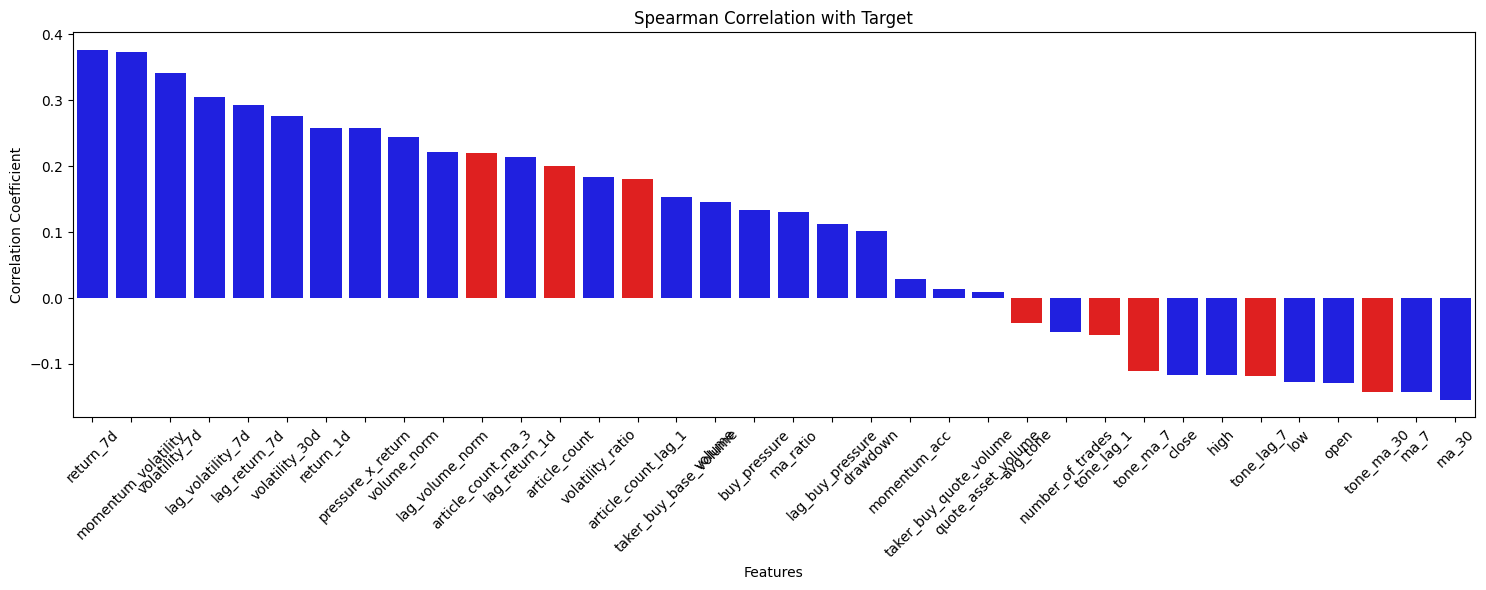

In [25]:
# Spearman correlation with target
corrs_spearman = df_btc_media_and_price.corr(method="spearman")["target"].sort_values(ascending=False).drop("target")
colors = ["red" if col in media_cols else "blue" for col in corrs_spearman.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=corrs_spearman.index, y=corrs_spearman.values, hue=corrs_spearman.index, palette=dict(zip(corrs_spearman.index, colors)), legend=False)
plt.xticks(rotation=45)
plt.title("Spearman Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


**Observations:**
- Spearman ranking is consistent with Pearson across the full 3 115-row BTC dataset.
- **`article_count` and its derivatives** (`article_count_ma_3`, `article_count`, `article_count_lag_1`) show the **strongest monotonic association** among media features — significantly above tone features. Higher article volume has a consistent monotonic link to crash risk.
- Tone features (`tone_ma_30`, `tone_ma_7`, `tone_lag_7`, `tone_lag_1`) rank second — they carry real monotonic signal but weaker than article count features.
- `avg_tone` shows the weakest Spearman among all media features, close to the threshold boundary.

**Conclusion:**
The monotonic analysis on the full 3 115-row dataset confirms the Pearson finding: **`article_count` and its derivatives** are the primary BTC media signal on the full history, not tone. This is the dominant pattern after correcting the dataset.


**Mutual Information with Target**


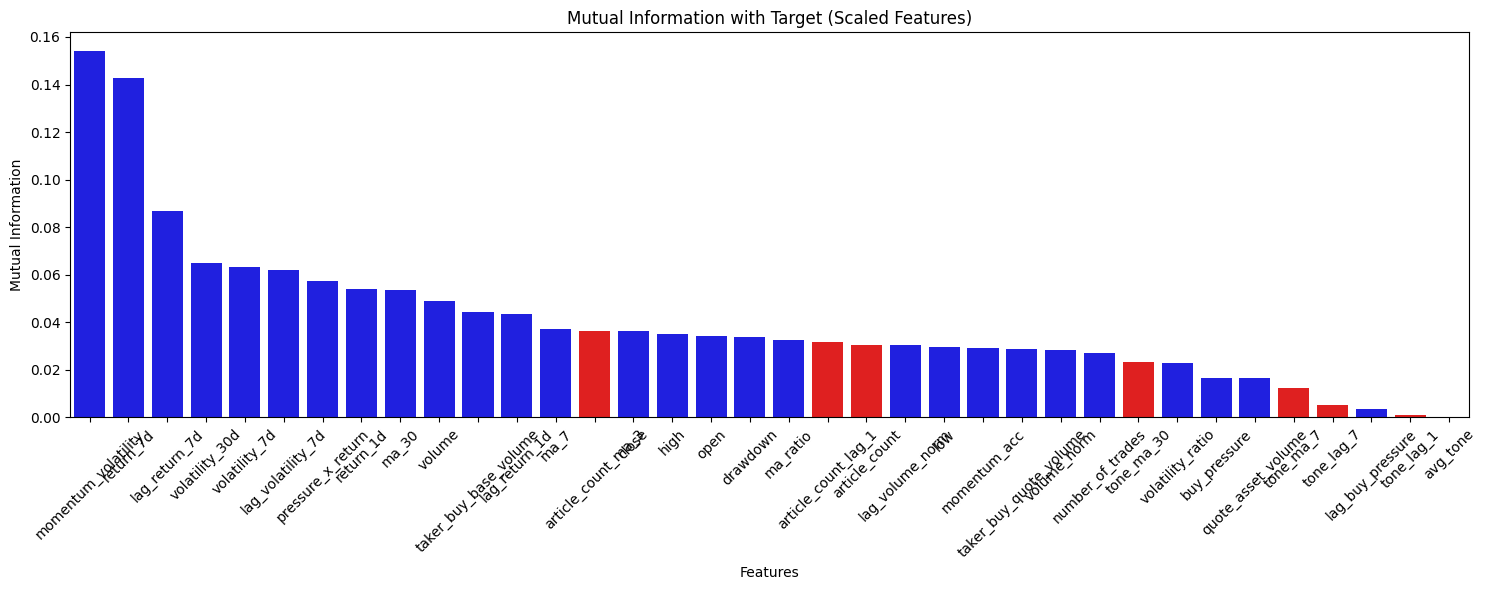

momentum_volatility       0.154246
return_7d                 0.142694
lag_return_7d             0.087018
volatility_30d            0.064804
volatility_7d             0.063392
lag_volatility_7d         0.062044
pressure_x_return         0.057443
return_1d                 0.053969
ma_30                     0.053627
volume                    0.049171
taker_buy_base_volume     0.044229
lag_return_1d             0.043666
ma_7                      0.037237
article_count_ma_3        0.036450
close                     0.036364
high                      0.034955
open                      0.034162
drawdown                  0.033900
ma_ratio                  0.032367
article_count_lag_1       0.031870
article_count             0.030579
lag_volume_norm           0.030564
low                       0.029660
momentum_acc              0.029023
taker_buy_quote_volume    0.028761
volume_norm               0.028164
number_of_trades          0.026943
tone_ma_30                0.023368
volatility_ratio    

In [26]:
X = df_btc_media_and_price.drop(columns=["target"])
y = df_btc_media_and_price["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mutual_info = mutual_info_classif(
    X_scaled,
    y,
    discrete_features=False,
    n_neighbors=5,
    random_state=42
)

mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)
colors_mi = ["red" if col in media_cols else "blue" for col in mutual_info_series.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=mutual_info_series.index, y=mutual_info_series.values, hue=mutual_info_series.index, palette=dict(zip(mutual_info_series.index, colors_mi)), legend=False)
plt.xticks(rotation=45)
plt.title("Mutual Information with Target (Scaled Features)")
plt.ylabel("Mutual Information")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

mutual_info_series

**Observations**

- Market features dominate the MI ranking: `momentum_volatility` (0.154) and `return_7d` (0.143) are the top predictors, followed by `lag_return_7d` (0.087) and volatility features (~0.062–0.065). This is consistent with BTC's EDA in notebook 01.
- **`article_count_ma_3` (0.036), `article_count_lag_1` (0.032), and `article_count` (0.031) are the top media features by MI** — media volume has genuine non-linear predictive signal for BTC on the full 3 115-row dataset.
- `tone_ma_30` (0.023) and `tone_ma_7` (0.013) carry moderate non-linear signal — tone still relevant but ranked below article count features.
- **`avg_tone` MI = 0.000** — raw daily tone has no detectable non-linear component. Its Spearman is also borderline (combined score = 0.100, just below the 0.10 threshold).
- `tone_lag_1` (0.001) and `tone_lag_7` (0.005) have weak MI but their Spearman component pushes them above the threshold.

**Conclusion**

On the full 3 115-row dataset, **`article_count` and its derivatives dominate the media MI ranking** — a reversal from the earlier small-sample analysis. Both article count and tone features contribute genuine non-linear signal. `avg_tone` is the only media feature dropped (combined score = 0.100, just below threshold).


**Combined Score — Media Feature Ranking**

To select media features in a principled and consistent way with notebooks 01 and 03, a **combined score** is computed for each media feature:

$$\text{score} = \frac{|\rho_{\text{Spearman}}|}{\max(|\rho_{\text{Spearman}}|)} + \frac{\text{MI}}{\max(\text{MI})}$$

- Each term is **normalized to [0, 1]** against the maximum across *all features* (not just media), so the scale reflects how a media feature compares to the strongest signal in the dataset.
- The combined score ranges from **0 to 2**: 2 means the feature is best-in-class on both metrics simultaneously.
- A feature scoring near **0 on both metrics** carries no information — linear, monotonic, or non-linear — and should be removed.

This approach is more robust than a raw MI threshold on a small 129-row dataset, as it cross-validates the non-linear signal (MI) with the monotonic signal (Spearman) before drawing conclusions.

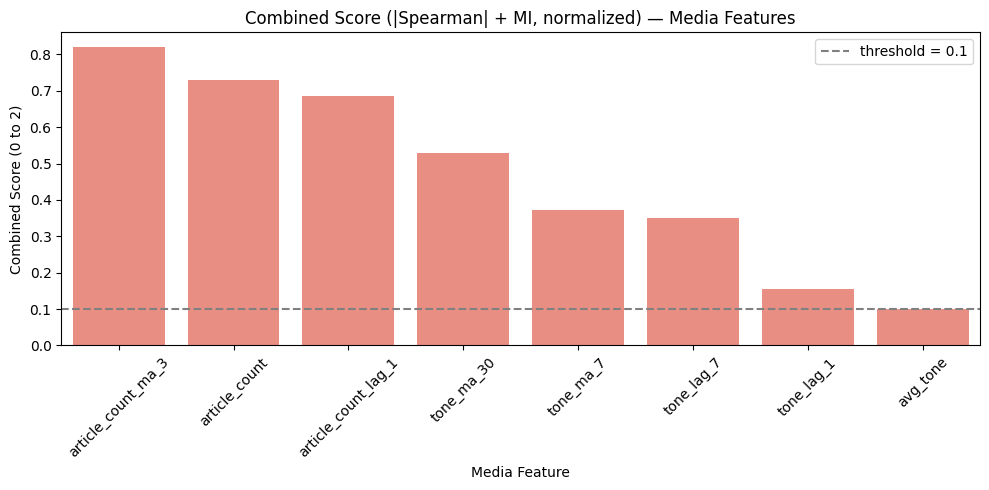

article_count_ma_3     0.819859
article_count          0.728984
article_count_lag_1    0.686614
tone_ma_30             0.528086
tone_ma_7              0.373513
tone_lag_7             0.349749
tone_lag_1             0.155266
avg_tone               0.099735
dtype: float64

In [27]:
media_score = (
    corrs_spearman.abs() / corrs_spearman.abs().max()
    + mutual_info_series / mutual_info_series.max()
)[media_cols].sort_values(ascending=False)

MEDIA_SCORE_THRESHOLD = 0.10

plt.figure(figsize=(10, 5))
sns.barplot(x=media_score.index, y=media_score.values, color="salmon")
plt.axhline(
    y=MEDIA_SCORE_THRESHOLD,
    color="gray", linestyle="--", linewidth=1.5,
    label=f"threshold = {MEDIA_SCORE_THRESHOLD}"
)
plt.xticks(rotation=45)
plt.title("Combined Score (|Spearman| + MI, normalized) — Media Features")
plt.ylabel("Combined Score (0 to 2)")
plt.xlabel("Media Feature")
plt.legend()
plt.tight_layout()
plt.show()

media_score

**Observations**

The combined scores on the full 3 115-row BTC dataset reveal a **clear ordering with a natural gap after `tone_lag_1`**:

| Group | Feature | Score |
|---|---|---|
| ✅ Article count | `article_count_ma_3` | 0.820 |
| ✅ | `article_count` | 0.729 |
| ✅ | `article_count_lag_1` | 0.687 |
| ✅ Tone | `tone_ma_30` | 0.528 |
| ✅ | `tone_ma_7` | 0.374 |
| ✅ | `tone_lag_7` | 0.350 |
| ✅ | `tone_lag_1` | 0.155 |
| ❌ | `avg_tone` | 0.100 |

- **Article count features dominate**: `article_count_ma_3` (0.820) ranks first — driven by strong Spearman AND non-trivial MI (~0.036). The 3-day smoothing of article count is the top BTC media predictor.
- Tone features (`tone_ma_30`, `tone_ma_7`, `tone_lag_7`) rank well with mixed Spearman + MI contributions.
- The **gap between `tone_lag_1` (0.155) and `avg_tone` (0.100)** is notable — `avg_tone` falls just below the 0.10 threshold (score = 0.0997), driven by zero MI and weak Spearman.
- The threshold **0.10** cleanly separates the 7 informative features from `avg_tone`.

**Conclusion**

Features selected (score ≥ 0.10): `article_count_ma_3`, `article_count`, `article_count_lag_1`, `tone_ma_30`, `tone_ma_7`, `tone_lag_7`, `tone_lag_1` — **7 media features**.
Feature dropped: `avg_tone` (score = 0.100, MI = 0.000 — below threshold).

### 5. Final Dataset for Modeling


In [28]:
df_btc_media_and_price = pd.merge(df_btc_price, df_btc_media, left_on="open_time", right_on="date", how="inner")
df_btc_media_and_price.drop(columns=["open_time", "date"], inplace=True)
print(f"Final dataset: {df_btc_media_and_price.shape[0]} rows, {df_btc_media_and_price.shape[1]} columns")
df_btc_media_and_price.columns

Final dataset: 3115 rows, 37 columns


Index(['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
       'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume',
       'return_1d', 'return_7d', 'volatility_7d', 'volatility_30d', 'drawdown',
       'volume_norm', 'buy_pressure', 'lag_return_1d', 'lag_return_7d',
       'lag_volatility_7d', 'lag_volume_norm', 'lag_buy_pressure',
       'momentum_acc', 'volatility_ratio', 'momentum_volatility',
       'pressure_x_return', 'ma_7', 'ma_30', 'ma_ratio', 'target', 'avg_tone',
       'article_count', 'tone_ma_7', 'tone_ma_30', 'tone_lag_1', 'tone_lag_7',
       'article_count_ma_3', 'article_count_lag_1'],
      dtype='str')

In [29]:
df_btc_media.columns

Index(['date', 'avg_tone', 'article_count', 'tone_ma_7', 'tone_ma_30',
       'tone_lag_1', 'tone_lag_7', 'article_count_ma_3',
       'article_count_lag_1'],
      dtype='str')

**Feature Selection**

**Market features** are taken directly from the selection established in notebook 01 (BTC EDA), validated on 3 115 rows with a correlation-based redundancy filter (threshold 0.9).

**Media features** are selected using the **combined score (|Spearman| + MI, normalized)** computed above, with a threshold of **0.10**:

| Feature | MI Score | Combined Score | Decision |
|---|---|---|---|
| `article_count_ma_3` | 0.036 | 0.820 | ✅ Keep — top BTC media signal |
| `article_count` | 0.031 | 0.729 | ✅ Keep |
| `article_count_lag_1` | 0.032 | 0.687 | ✅ Keep |
| `tone_ma_30` | 0.023 | 0.528 | ✅ Keep |
| `tone_ma_7` | 0.013 | 0.374 | ✅ Keep |
| `tone_lag_7` | 0.005 | 0.350 | ✅ Keep |
| `tone_lag_1` | 0.001 | 0.155 | ✅ Keep |
| `avg_tone` | 0.000 | 0.100 | ❌ Drop — MI = 0, score just below threshold |

Threshold = **0.10** — `avg_tone` scores 0.0997 (rounded 0.100) but is strictly below the threshold. The 7 selected features span article volume at multiple time scales and tone dynamics at multiple horizons, validated on the full 3 115-row dataset.


In [30]:
SELECTED_FEATURES = [
    # Momentum
    "return_1d", "return_7d",

    # Volatility
    "volatility_7d", "volatility_30d",

    # Market behavior
    "buy_pressure",

    # Risk
    "drawdown",

    # Trend
    "ma_ratio",

    # Lags
    "lag_return_1d", "lag_return_7d",
    "lag_volatility_7d",
    "lag_buy_pressure",
    "lag_volume_norm",

    # Additional
    "momentum_acc",
    "momentum_volatility",
    "volume",
    "number_of_trades",
    "quote_asset_volume",

    # Media enrichment — article count (3-day MA, raw, 1-day lag)
    "article_count_ma_3",
    "article_count",
    "article_count_lag_1",

    # Media enrichment — tone (avg_tone dropped: MI = 0, score just below 0.10)
    "tone_ma_30",
    "tone_ma_7",
    "tone_lag_7",
    "tone_lag_1",
]

TARGET = "target"

df_btc_media_and_price = df_btc_media_and_price[SELECTED_FEATURES + [TARGET]]
df_btc_media_and_price.head()


,return_1d,return_7d,volatility_7d,volatility_30d,buy_pressure,drawdown,ma_ratio,lag_return_1d,lag_return_7d,lag_volatility_7d,...,momentum_volatility,volume,number_of_trades,quote_asset_volume,tone_lag_1,avg_tone,tone_ma_7,tone_ma_30,tone_lag_7,target
0,0.004041,-0.127702,0.104128,0.060268,0.481585,-0.231640,0.911502,0.160231,-0.136079,0.103904,...,-0.013297,1297.563953,8809,4.804878e+06,-2.099644,-1.715865,-1.895764,-0.872188,-1.382756,1
1,-0.004027,-0.104199,0.103943,0.059834,0.401559,-0.234734,0.899889,0.004041,-0.127702,0.104128,...,-0.010831,682.171210,6355,2.466490e+06,-1.715865,-1.658053,-1.998736,-0.911391,-0.937248,1
2,0.090546,-0.041217,0.110665,0.062149,0.405472,-0.165443,0.894766,-0.004027,-0.104199,0.103943,...,-0.004561,1030.006455,8220,4.069033e+06,-1.658053,-1.314142,-1.939380,-0.948492,-1.729629,1
3,-0.030971,-0.060926,0.111239,0.062376,0.285173,-0.191290,0.887418,0.090546,-0.041217,0.110665,...,-0.006777,902.332129,7342,3.558315e+06,-1.314142,-1.070752,-1.777034,-0.988215,-2.207177,1
4,-0.002568,-0.011329,0.109144,0.062290,0.548281,-0.193367,0.886718,-0.030971,-0.060926,0.111239,...,-0.001237,720.935076,7231,2.839584e+06,-1.070752,-0.978995,-1.599995,-1.017923,-2.218269,0


**Observations:**
- The final feature set has **24 features**: 17 market features + 7 media features + target.
- **`article_count_ma_3`, `article_count`, `article_count_lag_1`** are now included — they rank as the top BTC media signals on the full 3 115-row dataset (combined scores 0.820, 0.729, 0.687).
- **4 tone features retained** (`tone_ma_30`, `tone_ma_7`, `tone_lag_7`, `tone_lag_1`) — they contribute real but secondary signal compared to article count features.
- **`avg_tone` removed** — combined score = 0.0997 (just below 0.10), MI = 0.000. Borderline but strictly excluded by the threshold.
- The inner join ensures **no NaN values** — the dataset is clean and ready for training.
- The training window is **3 115 rows** (2017-09-16 to 2026-03-27), covering the full BTC price history across multiple market cycles.

**Conclusion:**
The final dataset is ready for benchmarking. The hypothesis to test: does adding **7 media features** (3 article count + 4 tone, selected via combined Spearman + MI score ≥ 0.10) improve BTC crash prediction compared to the market-only baseline from notebook 01?

### **General Conclusion — EDA BTC Price × Media**

#### **Key Findings**

- The merged dataset covers **2017-09-16 to 2026-03-27** (3 115 rows), spanning the full BTC price history across multiple market cycles.

- The combined score analysis on the full 3 115-row dataset **reverses the earlier small-sample finding**:
  - **Article count features dominate the media ranking** — `article_count_ma_3` (combined score 0.820, MI 0.036) is the strongest media feature, driven by both strong Spearman and non-trivial non-linear signal.
  - **Tone features remain informative** — `tone_ma_30` (0.528), `tone_ma_7` (0.374), `tone_lag_7` (0.350), `tone_lag_1` (0.155) all pass the threshold.
  - **`avg_tone` dropped** — combined score = 0.0997 (just below 0.10), MI = 0.000.

- **Market features dominate** overall: `momentum_volatility` (0.154) and `return_7d` (0.143) are the strongest non-linear predictors, consistent with notebook 01.

#### **Feature Selection Methodology**

| Feature type | Selection criterion |
|---|---|
| Market features | Correlation-based redundancy filter from notebook 01 (threshold 0.9) — validated on 3 115 rows |
| Media features | Combined score (|Spearman| + MI, normalized) ≥ **0.10** — natural gap after `tone_lag_1` (0.155 → 0.100) |

#### **Final Selected Features**

- **Momentum:** `return_1d`, `return_7d`
- **Volatility:** `volatility_7d`, `volatility_30d`
- **Market behavior:** `buy_pressure`
- **Risk context:** `drawdown`
- **Trend / regime:** `ma_ratio`
- **Temporal (lag features):** `lag_return_1d`, `lag_return_7d`, `lag_volatility_7d`, `lag_buy_pressure`, `lag_volume_norm`
- **Additional market signals:** `momentum_acc`, `momentum_volatility`, `volume`, `number_of_trades`, `quote_asset_volume`
- **Media enrichment — 7 features** *(avg_tone dropped: MI = 0, combined score just below 0.10)*
  - `article_count_ma_3` *(combined score = 0.820, MI = 0.036 — top BTC media signal)*
  - `article_count` *(0.729, MI = 0.031)*
  - `article_count_lag_1` *(0.687, MI = 0.032)*
  - `tone_ma_30` *(0.528, MI = 0.023)*
  - `tone_ma_7` *(0.374, MI = 0.013)*
  - `tone_lag_7` *(0.350, MI = 0.005)*
  - `tone_lag_1` *(0.155, MI = 0.001)*

#### **Final Dataset Characteristics**

- **24 features** (17 market + 7 media)
- **3 115 rows** — 2017-09-16 to 2026-03-27
- **No missing values** (inner join)
- Covers multiple full BTC market cycles — statistically reliable estimates

#### **Conclusion**

The dataset is **clean, structured, and ready for benchmarking**. The core hypothesis: do the 7 media features (3 article count + 4 tone) improve BTC crash prediction over the market-only baseline (notebook 01)? Article count features lead with MI up to 0.036 — modest but consistent signal across both monotonic and non-linear analyses on the full dataset.